# **Question 3: Multi-Class Segmentation for Underwater Imagery**

In this question, you should finetune a **pretrained U-Net** model for **multi-class segmentation** of underwater images. Your segmentation model will classify each pixel into **one of 8 classes**.

**Dataset:** SUIM (Semantic Segmentation of Underwater Imagery)

| Object Category | Class ID |
|----------------|----------|
| Background (waterbody) | 0 |
| Human divers | 1 |
| Aquatic plants and sea-grass | 2 |
| Wrecks and ruins | 3 |
| Robots (AUVs/ROVs/instruments) | 4 |
| Reefs and invertebrates | 5 |
| Fish and vertebrates | 6 |
| Sea-floor and rocks | 7 |

Complete the code cells below.

---

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q3-stage3-2026")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mohammad2012191/q3-stage3-2026


## **TASK 1: Dataset Class**
- Build a custom dataset class to load images and masks.
- Use Dataloaders to prepare your data.
- Display some images and their corresponding masks.



In [2]:
def remap_mask(mask):
    # Remaps a mask's pixel values to a consecutive range starting at 0
    mask = mask.long()
    unique_values = torch.unique(mask)
    remapped_mask = torch.zeros_like(mask)

    for new_val, old_val in enumerate(sorted(unique_values.tolist())):
        remapped_mask[mask == old_val] = new_val

    return remapped_mask


> **The function given above (pre-provided in the lab), `remap_mask`, is redundant as per my understanding. As the data will show later, the masks are already mapped from 0 to 7, making this function useless. On the contrary, when I had tried to use it, it was causing incorrect results because:**
>
> **Sometimes let's say only 3 classes were present, e.g. 0, 3, 5. It would remap them to 0, 1, 2 respectively, causing incorrect results/training.**


In [3]:
# TO DO
from torch.utils.data import DataLoader, Dataset
from glob import glob
import os
from PIL import Image
from sklearn.model_selection import train_test_split

class CustomDS(Dataset):

  def __init__(self, root_dir, split = 'train', transform = None, target_transform = None):
    self.root_dir = os.path.join(root_dir, 'dataset')
    self.image_paths = [os.path.join(self.root_dir, fp) for fp in glob('images/*.jpg',root_dir = self.root_dir)]
    # using list comprehension to convert from relative to absolute path (i.e. adding root_dir to each path in the first place)
    self.masks = [fp.replace('images/', 'masks/').replace('.jpg', '.png') for fp in self.image_paths]
    # above is self explanatory. this will also make image_paths[i] correspond with masks[i] i.e.
    # corresponding masks and images are lined up properly
    if split == 'train':
      self.image_paths, _, self.masks,_ = train_test_split(self.image_paths, self.masks, test_size=0.2, random_state = 42)
      # order is X_tr, X_test, y_tr, y_test

    elif split == 'test':
      _, self.image_paths, _, self.masks = train_test_split(self.image_paths, self.masks, test_size=0.2, random_state = 42)
    # maybe not the best way to split. but I am using
    # random_state = 42 so both initiations will ensure
    # that the same labels go to test and the same to train/test
    # so no image from an instance w split = 'train' should be in another instance w split = 'test'
    # and vice versa.

    self.transform = transform
    self.target_transform = target_transform
  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):

    img = Image.open(self.image_paths[idx]).convert('RGB')
    mask = Image.open(self.masks[idx]).convert('L')
    if self.transform:
      img = self.transform(img)
    if self.target_transform:
      mask = self.target_transform(mask)
    #mask = remap_mask(mask) redundant. already mapped from 0-7
    return img, mask

## **TASK 2: Model Class**
- **Use a pretrained U-Net** (from `segmentation_models_pytorch`) with "efficientnet-b1" as an encoder.

In [4]:
from torchvision.transforms import Compose, InterpolationMode, Resize, ToTensor, PILToTensor, Normalize
transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

target_transform = Compose([
    Resize((224, 224), interpolation=InterpolationMode.NEAREST),
    PILToTensor()
])

In [5]:
# TO DO
train_ds = CustomDS(path, 'train', transform = transform, target_transform = target_transform)
test_ds = CustomDS(path, 'test', transform = transform, target_transform = target_transform)

In [6]:
# TO DO
# to prove that they don't contain same images (showing proff my split strat works)

for fp in test_ds.image_paths:
  if fp in train_ds.image_paths:
    print("😱")
    break
print('done so far w/o 😱 i.e. my split strat works!! :DDDD')

done so far w/o 😱 i.e. my split strat works!! :DDDD


In [7]:
train_loader = DataLoader(train_ds, 4, shuffle=True)
test_loader = DataLoader(test_ds, 4)

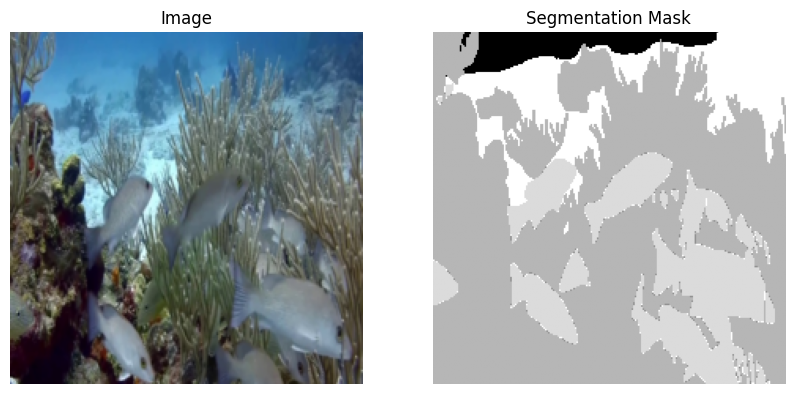

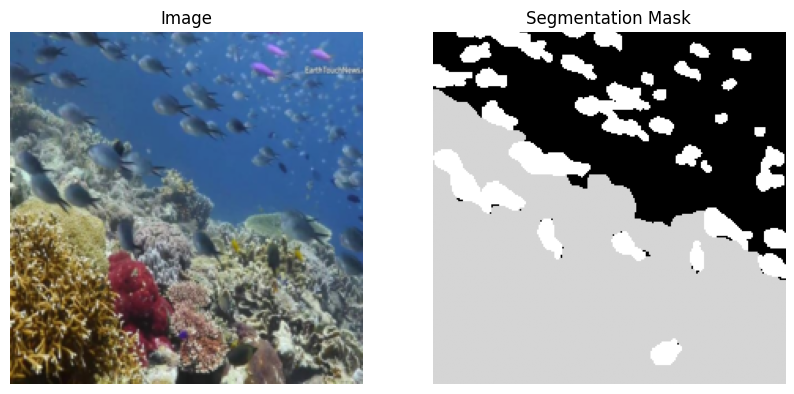

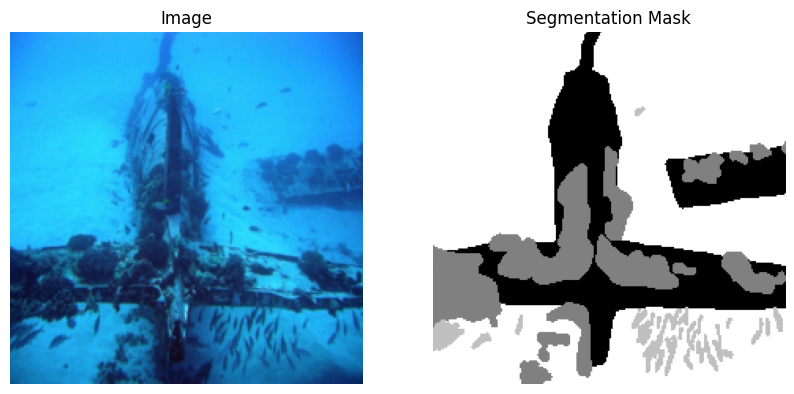

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.numpy().transpose(1, 2, 0)  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img


for i in range(3):
    img, mask = train_ds[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(denormalize(img))  # Convert (C, H, W) to (H, W, C)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
    plt.show()


In [9]:
# TO DO
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00


In [10]:
import segmentation_models_pytorch as smp
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
display(device)

model = smp.Unet(
    encoder_name="efficientnet-b1",  # as asked used effnet b1
    encoder_weights="imagenet",
    in_channels=3,
    classes=8,  # 8 output channels
).to(device)

'cuda'

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

## **TASK 3: Training and Validation Loops**
- Define the training and validation loops.

In [11]:
# TO DO
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)  # mask shape becomes [N, H, W]

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)    # mask shape becomes [N, H, W]

            outputs = model(images)  # Now [N, H, W]
            loss = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)

## **TASK 4: Running Training**
- Define the loss and the optimizer.
- Train the model.
- Print the training and validation losses.
- Plot loss curve.

In [12]:
# TO DO
from torch import nn

criterion = nn.CrossEntropyLoss() # cuz multiclass
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 15  # Define number of epochs
train_losses = []
val_losses = []

# Training Loop
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

100%|██████████| 40/40 [00:06<00:00,  6.61it/s]


Epoch 1/15: Train Loss = 2.1397, Val Loss = 1.9641


100%|██████████| 40/40 [00:03<00:00, 10.57it/s]


Epoch 2/15: Train Loss = 1.7443, Val Loss = 1.5661


100%|██████████| 40/40 [00:03<00:00, 10.62it/s]


...

Epoch 13/15: Train Loss = 0.7996, Val Loss = 0.8775


100%|██████████| 40/40 [00:03<00:00, 10.67it/s]


Epoch 14/15: Train Loss = 0.7780, Val Loss = 0.8905


100%|██████████| 40/40 [00:03<00:00, 10.61it/s]


Epoch 15/15: Train Loss = 0.7676, Val Loss = 0.8610


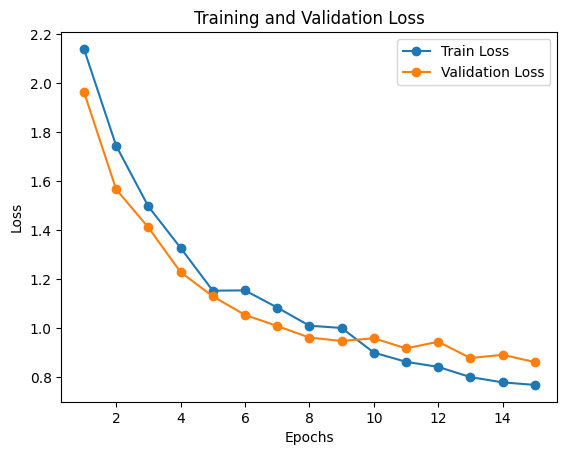

In [13]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## **TASK 5: Visualizing Predictions**
- Visualize your model's predictions against the ground truth for several images.

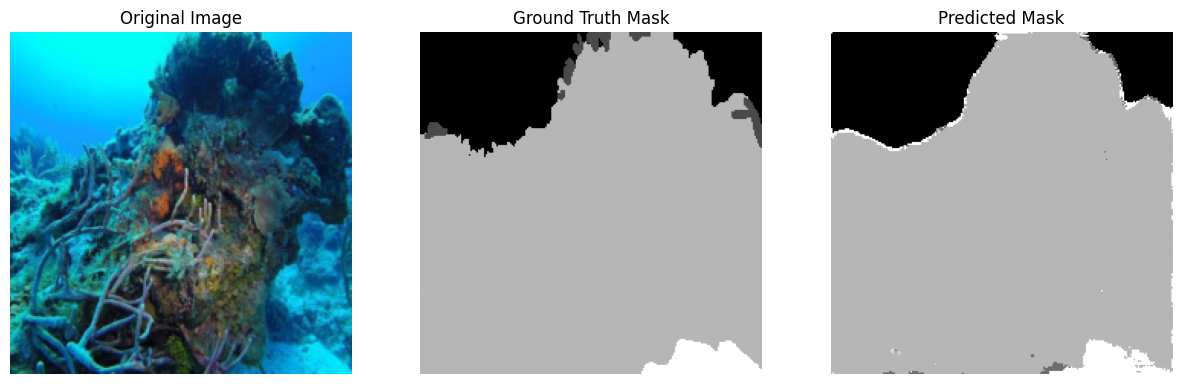

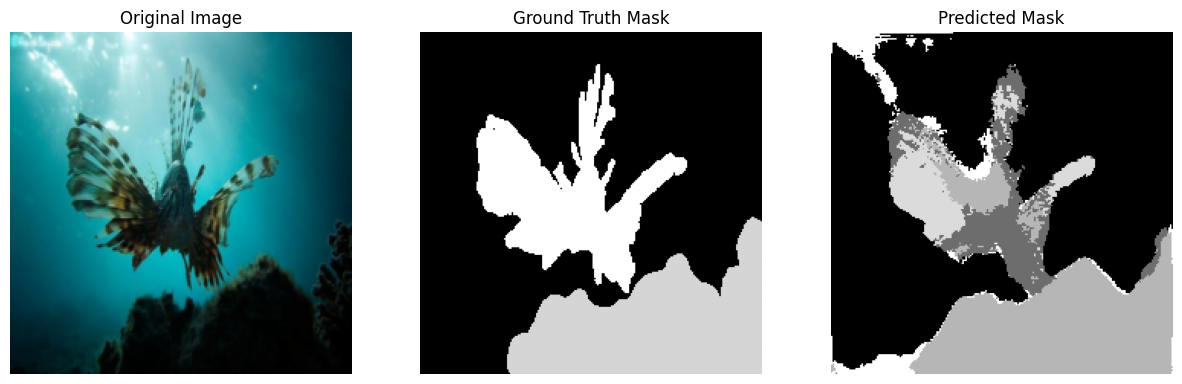

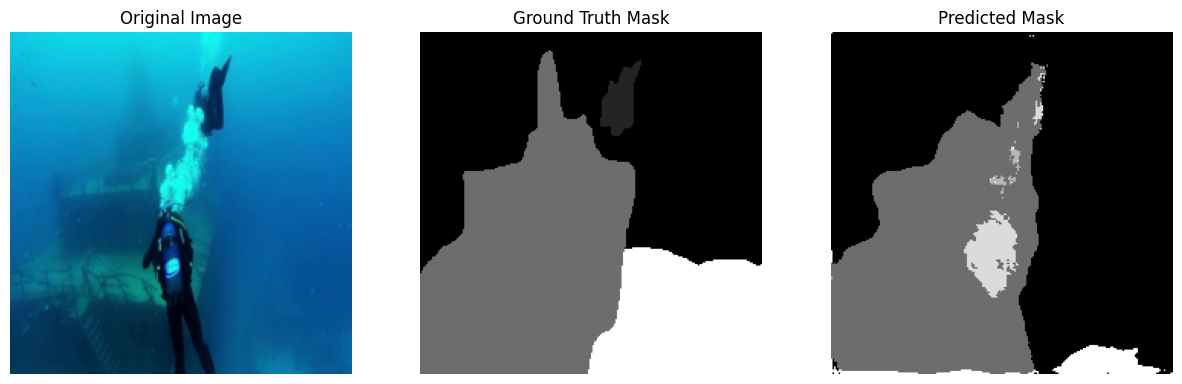

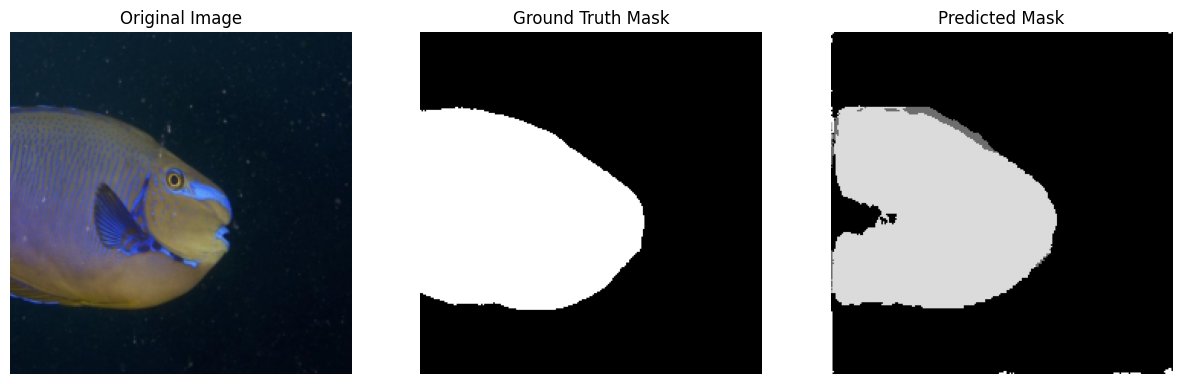

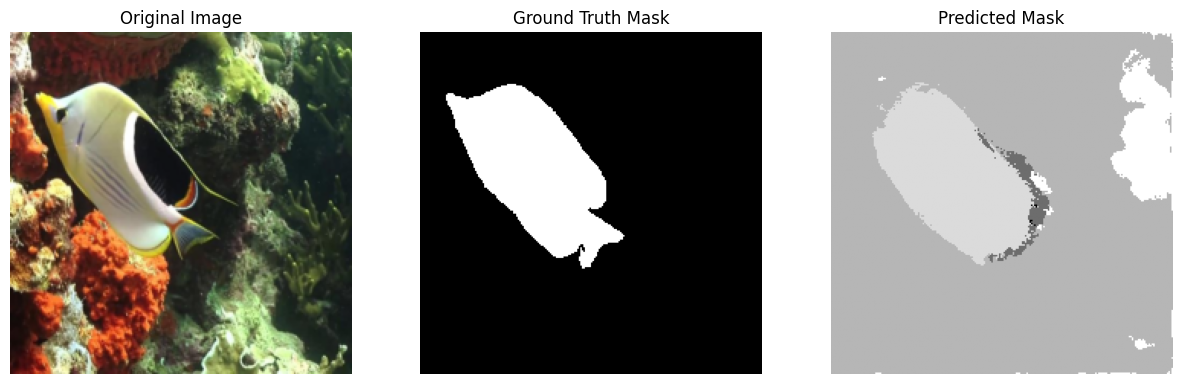

In [14]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Function to denormalize images
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


model.eval()


test_samples = random.sample(range(len(test_ds)), 5)

for idx in test_samples:
    img, mask = test_ds[idx]

    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device))
    # EDITED LINES: HERE WE NEED TO ARGMAX FOR MULTICLASS MASK.
    pred_mask = torch.softmax(pred_mask, dim=1)
    pred_mask = torch.argmax(pred_mask, dim=1).cpu().squeeze()
    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image (Denormalized)
    axes[0].imshow(denormalize(img))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Ground Truth Mask
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    # Predicted Mask
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.show()